In [1]:
import os
import torch
import torchvision
from attacks.analytic_attack import ImprintAttacker
from modifications.imprint import CNN_network
from utils.breaching_utils import *
from PIL import Image
import time
from torch.utils.data import Dataset
import random
from torchvision import transforms
from utils.analysis import report
from datetime import datetime
import numpy as np
import torch
from scipy.fftpack import dct

(CVXPY) Mar 31 11:30:46 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Mar 31 11:30:46 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')


In [2]:
def create_dct_matrix(N):
    """Creates an orthogonal DCT (type-II) matrix of size N x N."""
    dct_matrix = np.zeros((N, N))
    for k in range(N):
        v = np.cos(np.pi * k * (np.arange(N) + 0.5) / N)
        if k == 0:
            v = v * np.sqrt(1/N)
        else:
            v = v * np.sqrt(2/N)
        dct_matrix[k, :] = v
    return dct_matrix

def patchwise_dct(image, patch_size=8):
    """
    Apply patchwise DCT on an image.
    Returns both DCT coefficients and the DCT matrix.
    """
    H, W = image.shape[:2]
    C = 1 if image.ndim == 2 else image.shape[2]

    patches = []
    for y in range(0, H, patch_size):
        for x in range(0, W, patch_size):
            patch = image[y:y+patch_size, x:x+patch_size]
            if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
                continue  # skip incomplete patches

            if C == 1:
                patch_dct = dct(dct(patch.T, norm="ortho").T, norm="ortho")
            else:
                patch_dct = np.stack([
                    dct(dct(patch[..., c].T, norm="ortho").T, norm="ortho")
                    for c in range(C)
                ], axis=-1)

            patches.append(patch_dct)

    # return both patches and the fixed DCT matrix
    dct_matrix = create_dct_matrix(patch_size)
    return np.array(patches), dct_matrix


In [3]:
class myDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.samples = []
        self.transform = transform

        # Walk through each subfolder (e.g., lung_aca, lung_n, lung_scc)
        for label_folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, label_folder)
            if not os.path.isdir(folder_path):
                continue
            for fname in os.listdir(folder_path):
                if fname.endswith('.jpeg') or fname.endswith('.jpg') or fname.endswith('.png'):
                    self.samples.append((os.path.join(folder_path, fname), label_folder))

        # Label encoding (e.g., {"lung_aca": 0, ...})
        self.label2id = {label: idx for idx, label in enumerate(sorted(set(label for _, label in self.samples)))}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.label2id[label]

def load_dataset(name, transform):
    if name == "Imagenet":
        return torchvision.datasets.ImageNet(
            root="./data",
            split="val",
            transform=transform
        )
    elif name == "MNIST":
        return torchvision.datasets.MNIST(
            root="./data", train=False, download=True, transform=transform
        )
    elif name == "CIFAR10":
        return torchvision.datasets.CIFAR10(
            root="./data", train=False, download=True, transform=transform
        )
    elif name == "Lung":
        dataset_path = "./data/Lung_Colon/lung_colon_image_set/lung_image_sets/"
        return myDataset(root_dir=dataset_path, transform=transform)
    elif name == "HAM":
        dataset_path = "./data/HAM10000/"
        return myDataset(root_dir=dataset_path, transform=transform)
    else:
        raise ValueError(f"Unknown dataset: {name}")



# Attack begins here:

first layer weights: tensor([[0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
        [0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
        [0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
        ...,
        [0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
        [0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
        [0.0003, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003]],
       device='cuda:0')
linear weight type: avg
before weight_grad: torch.Size([1024, 12288])
before bias_grad: torch.Size([1024])
before sub bias_grad = 0: 254
after sub bias_grad = 0: 1022
✅ Success to find a solution at index 0
✅ Success to find a solution at index 1
Number of alpha_hats: 2
alpha_hats[0]: type=<class 'numpy.ndarray'>, shape=(3072,)
alpha_hats[1]: type=<class 'numpy.ndarray'>, shape=(3072,)
Saved x_hat to: x_hat/x_hat_20260331_233407.pt
Initially produced 2 hits.
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/test/anaconda3/envs/mmgia/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/test/anaconda3/envs/mmgia/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/test/anaconda3/envs/mmgia/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth
Reduced to 1 unique images after LPIPS filtering.


INFO:utils.analysis:METRICS: | MSE: 0.0000 | PSNR: 150.63 | FMSE: 0.0000e+00 | LPIPS: 0.00|
 R-PSNR: 150.63 | IIP-none:  nan% | SSIM: 0.0000 | Label Acc: 100.00%


Reconstructed_user_data forward
True_user_data forward
MSE: 8.643259719054441e-16, PSNR: 150.6332244873047, LPIPS: 6.243765134908083e-14
Figures/CIFAR10/reconstructed_bs1_20260331_233409.pdf
[INFO] Figure saved to: Figures/CIFAR10/true_bs1_20260331_233409.pdf
[INFO] Figure saved to: Figures/CIFAR10/reconstructed_bs1_20260331_233409.pdf


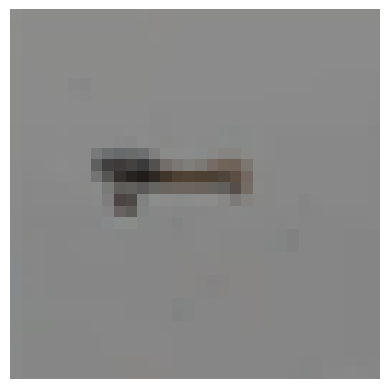

In [4]:
# set seeds
seed_all = int(time.time()) % (2**32 - 1)
random.seed(seed_all)
torch.manual_seed(seed_all)
torch.cuda.manual_seed_all(seed_all)

batch_size =32
dataset_name ='CIFAR10'
num_bins = 1024
if dataset_name=='Imagenet':
    transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),  # Ensures square shape
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    dataset = torchvision.datasets.ImageNet(root="./data", split="val", transform=transform)
    input_dim = 3*224*224

elif dataset_name=='CIFAR10':
    transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    ),
])
    dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)   
    input_dim = 3*32*32
    

dataset = load_dataset(dataset_name, transform)

random.seed(123) # You can change this to get a new batch. 
samples = [dataset[i] for i in random.sample(range(len(dataset)), batch_size)]

data = torch.stack([sample[0] for sample in samples]).to('cuda')
labels = torch.tensor([sample[1] for sample in samples]).to('cuda')

setup = dict(device=torch.device("cuda" if torch.cuda.is_available() else "cpu"), dtype=torch.float)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_network(input_dim, num_bins=num_bins, dataset=dataset_name)
model.eval()
loss_fn = torch.nn.CrossEntropyLoss()


secret = dict(conv_weight_idx1=0,conv_weight_idx2=1,weight_idx_second=2, bias_idx_second=3,weight_idx_third=4, 
              bias_idx_third=5, shape=tuple(data_cfg_default.shape), structure=model.structure)
secrets = {"ImprintBlock": secret}


model = model.to(device) 
conv1 = model.conv1  # First conv weight

# Move data and labels to CUDA device
data = data.to(device)
labels = labels.to(device)
attacker = ImprintAttacker(model, loss_fn, attack_cfg_default, setup)

# Server-side computation:
queries = [dict(parameters=[p for p in model.parameters()], buffers=[b for b in model.buffers()])]
server_payload = dict(queries=queries, data=data_cfg_default)
loss = loss_fn(model(data), labels)

shared_data = dict(
    gradients=[torch.autograd.grad(loss, model.parameters(),retain_graph=True)],
    buffers=None,
    num_data_points=1,
    labels=labels,
    local_hyperparams=None,
)

# Attack:
true_user_data = {'data': data.to(device), 'labels': labels.to(device)}

# only to get the shape
img = data[0]                  # shape (C, H, W)
img_np = img.permute(1, 2, 0).cpu().numpy()  # (H, W, C)

# Apply patchwise DCT (8x8)
coeffs, D = patchwise_dct(img_np, patch_size=8)

# check sparsity
threshold = 1e-5
coeffs = coeffs.reshape(-1)  # flatten all patches and channels
num_zeros = np.sum(np.abs(coeffs) < threshold)
sparsity_ratio = num_zeros / coeffs.size


D_flat = np.kron(D, D)             # (p*p, p*p)
D_flat_torch = torch.from_numpy(D_flat).float().to(device)


# Number of patches per channel
num_patches_per_channel = (32 // 8) * (32// 8)  # 4

# Block-diagonal for one channel
torch.cuda.empty_cache()
blocks = [D_flat_torch for _ in range(num_patches_per_channel)]
Psi_channel = torch.block_diag(*blocks)  # shape: (1024, 1024)

# Block-diagonal for all channels
Psi = torch.block_diag(*[Psi_channel for _ in range(3)])  # shape: (3072, 3072)
# print("Big patchwise DCT matrix shape:", Psi.shape)
num_patches = Psi.shape[1]
Psi_reshaped = Psi.T.reshape(num_patches, 3, 32, 32)  # [batch, C, H, W]

# Convert to float tensor
Psi_reshaped = Psi_reshaped.float()

A_conv= conv1(Psi_reshaped)
A = A_conv.reshape(A_conv.shape[0], -1)

reconstructed_user_data_conv, stats_conv = attacker.reconstruct(server_payload, 
shared_data, secrets,Psi,A, defense='dp',dryrun=False)

metrics = report(reconstructed_user_data_conv,
    true_user_data,
    server_payload,
    model, compute_ssim=False) # Can change to true and install a package...
print(f"MSE: {metrics['mse']}, PSNR: {metrics['psnr']}, LPIPS: {metrics['lpips']}")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = f"Figures/{dataset_name}/reconstructed_bs{batch_size}_{timestamp}.pdf"
save_path_true = f"Figures/{dataset_name}/true_bs{batch_size}_{timestamp}.pdf"
print(save_path)
plot_data(cfg=data_cfg_default, user_data=true_user_data, setup=setup, save_path=save_path_true)
plot_data(cfg=data_cfg_default, user_data=reconstructed_user_data_conv, setup=setup, save_path=save_path)